In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3    # RGB
EPOCHS = 50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset)

68

(32, 256, 256, 3)
[1 1 0 1 0 1 0 1 1 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 0 0 2 0 1 1 1 1]
tf.Tensor(
[[[146. 136. 147.]
  [135. 125. 136.]
  [152. 142. 153.]
  ...
  [132. 122. 133.]
  [127. 117. 128.]
  [125. 115. 126.]]

 [[135. 125. 136.]
  [ 94.  84.  95.]
  [133. 123. 134.]
  ...
  [133. 123. 134.]
  [129. 119. 130.]
  [128. 118. 129.]]

 [[138. 128. 139.]
  [158. 148. 159.]
  [152. 142. 153.]
  ...
  [138. 128. 139.]
  [139. 129. 140.]
  [141. 131. 142.]]

 ...

 [[193. 190. 199.]
  [192. 189. 198.]
  [191. 188. 197.]
  ...
  [187. 181. 191.]
  [188. 182. 192.]
  [190. 184. 194.]]

 [[190. 187. 196.]
  [191. 188. 197.]
  [191. 188. 197.]
  ...
  [186. 180. 190.]
  [187. 181. 191.]
  [189. 183. 193.]]

 [[187. 184. 193.]
  [189. 186. 195.]
  [190. 187. 196.]
  ...
  [183. 177. 187.]
  [184. 178. 188.]
  [186. 180. 190.]]], shape=(256, 256, 3), dtype=float32)
(32, 256, 256, 3)
[1 1 0 1 0 1 0 1 1 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 0 0 2 0 1 1 1 1]
tf.Tensor(
[[[113. 100. 107.]
  [110.  97. 104

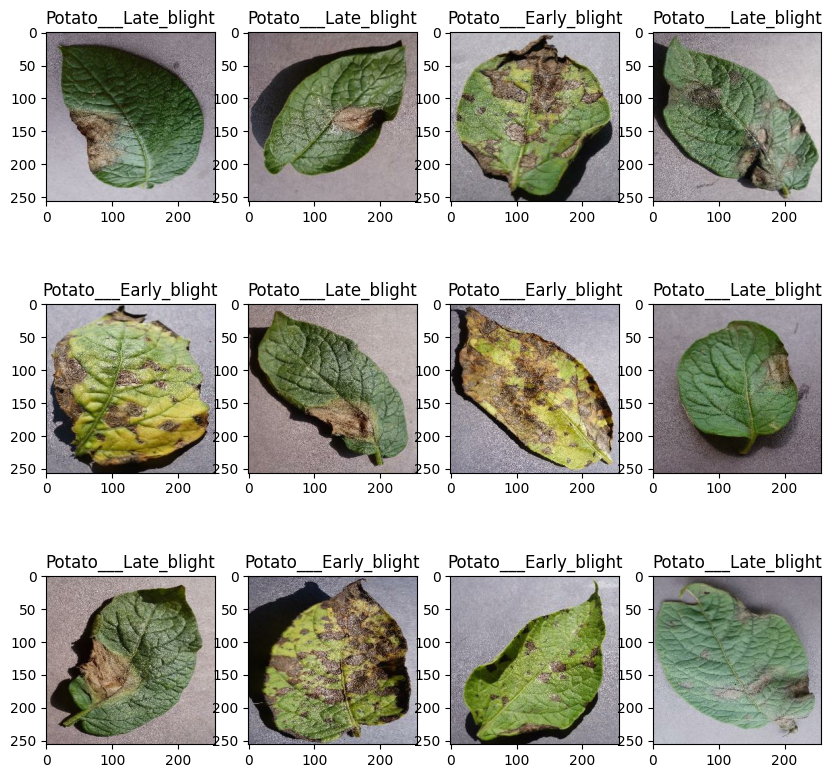

In [6]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        print(image_batch.shape)
        print(label_batch.numpy())
        print(image_batch[i])
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])


### Spliting the dataset into train-test-split (80-10-10)

In [7]:
train_size = 0.8   # Training percentage = 80%
len(dataset)*train_size  # 68 * 0.8 = 54.40 = take first 54 batches(each batch has 32 samples) to train the model

54.400000000000006

In [8]:
train_Ds = dataset.take(54)
len(train_Ds)

54

In [9]:
rest_Ds = dataset.skip(54)   # skip the first 54 batches and rest one will be for test and validation set
len(rest_Ds)

14

In [10]:
validation_size = 0.1    # 10% validation set
len(dataset)*validation_size

6.800000000000001

In [11]:
val_Ds = rest_Ds.take(6)
len(val_Ds)

6

In [12]:
test_ds = rest_Ds.skip(6)
len(test_ds)

8

In [13]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(ds_size*train_split)
    val_size = int(ds_size*val_split)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds,val_ds,test_ds

In [14]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [15]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


### Image caching , prefetching -- dataset is optimized for training performance

In [16]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

### Image Preprocessing

In [19]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])